In [1]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from time import perf_counter

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

from sklearn.model_selection import train_test_split

import numpy as np
import uproot as up
import awkward as ak
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
PHOTON1_FILE = "../HEPMC-testing/photon1_test_50000.root"
PHOTON2_FILE = "../HEPMC-testing/photon2_test_50000.root"
NEUTRON_FILE = "../HEPMC-testing/neutron_test_50000.root"

TREE_NAME = "events"

# Geometry assumptions
ZDC_FACE_Z_MM = 35856.4
ZDC_HALF_WIDTH_X_MM = 300.0
ZDC_HALF_WIDTH_Y_MM = 300.0

# If files are still in the unrotated meson-structure frame, keep this true.
# If they are already in the ZDC/proton-beam frame, set ROTATE_TO_ZDC_FRAME = False.
ROTATE_TO_ZDC_FRAME = True
ROTATION_THETA_RAD = 0.025

# Masses in GeV
M_GAMMA = 0.0
M_NEUTRON = 0.939565
M_PI0 = 0.134977
M_LAMBDA = 1.115683

# Lambda c tau in mm
LAMBDA_CTAU_MM = 78.9

In [3]:
WSI_FRONT_Z_MM = 35856.4

ZDC_TUNGSTEN_THICKNESS_MM = 3.5
ZDC_GLUE_THICKNESS_MM = 0.11
ZDC_PAD_THICKNESS_MM = 0.320
ZDC_PCB_THICKNESS_MM = 1.6
ZDC_SI_AIR_THICKNESS_MM = 1.0

WSI_LAYER_THICKNESS_MM = (
    ZDC_TUNGSTEN_THICKNESS_MM
    + ZDC_GLUE_THICKNESS_MM
    + ZDC_PAD_THICKNESS_MM
    + ZDC_GLUE_THICKNESS_MM
    + ZDC_PCB_THICKNESS_MM
    + ZDC_SI_AIR_THICKNESS_MM
)

WSI_SI_CENTER_OFFSET_MM = (
    ZDC_TUNGSTEN_THICKNESS_MM
    + ZDC_GLUE_THICKNESS_MM
    + 0.5 * ZDC_PAD_THICKNESS_MM
)

WSI_LAYER_Z_MM = (
    WSI_FRONT_Z_MM
    + WSI_SI_CENTER_OFFSET_MM
    + np.arange(20) * WSI_LAYER_THICKNESS_MM
)

In [4]:
def assign_layers_from_geometry(z_column, layer_z=WSI_LAYER_Z_MM, tolerance=1.0):
    all_layers = []

    for zevt in z_column:
        zevt = np.asarray(zevt)

        if len(zevt) == 0:
            all_layers.append(np.array([], dtype=np.int32))
            continue

        dz = np.abs(zevt[:, None] - layer_z[None, :])
        layers = np.argmin(dz, axis=1)
        min_dz = dz[np.arange(len(zevt)), layers]

        valid = min_dz < tolerance

        # Use -1 for hits that do not match a known WSi silicon layer
        layers_out = np.full(len(zevt), -1, dtype=np.int32)
        layers_out[valid] = layers[valid]

        all_layers.append(layers_out)

    return np.array(all_layers, dtype=object)

In [5]:
def rotate_vectors_numpy(x, y, z, theta=0.025):
    c = np.cos(theta)
    s = np.sin(theta)

    x_rot =  c * x + s * z
    y_rot =  y
    z_rot = -s * x + c * z

    return x_rot, y_rot, z_rot


def first_per_event(arr):
    return np.array([x[1] if len(x) > 1 else np.nan for x in arr])


def load_first_mc_particle(filename, mass_assumption):
    tree = up.open(filename)[TREE_NAME]

    vx = first_per_event(tree["MCParticles.vertex.x"].array(library="np"))
    vy = first_per_event(tree["MCParticles.vertex.y"].array(library="np"))
    vz = first_per_event(tree["MCParticles.vertex.z"].array(library="np"))

    px = first_per_event(tree["MCParticles.momentum.x"].array(library="np"))
    py = first_per_event(tree["MCParticles.momentum.y"].array(library="np"))
    pz = first_per_event(tree["MCParticles.momentum.z"].array(library="np"))

    mass = np.full_like(px, mass_assumption, dtype=float)

    if ROTATE_TO_ZDC_FRAME:
        vx, vy, vz = rotate_vectors_numpy(vx, vy, vz, ROTATION_THETA_RAD)
        px, py, pz = rotate_vectors_numpy(px, py, pz, ROTATION_THETA_RAD)

    p = np.sqrt(px**2 + py**2 + pz**2)
    E = np.sqrt(p**2 + mass**2)

    return {
        "vx": vx, "vy": vy, "vz": vz,
        "px": px, "py": py, "pz": pz,
        "p": p,
        "E": E,
        "m": mass,
    }

def extract_hit_information(filename):
    tree = up.open(filename)[TREE_NAME]

    wsi_hit_x = tree["ZDC_WSi_Hits.position.x"].array(library="np")
    wsi_hit_y = tree["ZDC_WSi_Hits.position.y"].array(library="np")
    wsi_hit_z = tree["ZDC_WSi_Hits.position.z"].array(library="np")
    wsi_hit_E = tree["ZDC_WSi_Hits.energy"].array(library="np")

    if ROTATE_TO_ZDC_FRAME:
        wsi_hit_x, wsi_hit_y, wsi_hit_z = rotate_vectors_numpy(wsi_hit_x, wsi_hit_y, wsi_hit_z, ROTATION_THETA_RAD)

    return wsi_hit_x, wsi_hit_y, wsi_hit_z, wsi_hit_E

def project_to_zdc(p):
    with np.errstate(divide="ignore", invalid="ignore"):
        dz = ZDC_FACE_Z_MM - p["vz"]
        x_zdc = p["vx"] + (p["px"] / p["pz"]) * dz
        y_zdc = p["vy"] + (p["py"] / p["pz"]) * dz
    return x_zdc, y_zdc


def intersects_zdc(x, y):
    return (
        np.isfinite(x) &
        np.isfinite(y) &
        (np.abs(x) < ZDC_HALF_WIDTH_X_MM) &
        (np.abs(y) < ZDC_HALF_WIDTH_Y_MM)
    )

def filter_accepted_events(filename_gamma1, filename_gamma2, filename_neutron):
    g1 = load_first_mc_particle(filename_gamma1, M_GAMMA)
    g2 = load_first_mc_particle(filename_gamma2, M_GAMMA)
    n  = load_first_mc_particle(filename_neutron, M_NEUTRON)

    x1, y1 = project_to_zdc(g1)
    x2, y2 = project_to_zdc(g2)
    xn, yn = project_to_zdc(n)

    acc1 = intersects_zdc(x1, y1)
    acc2 = intersects_zdc(x2, y2)
    accn = intersects_zdc(xn, yn)

    forward = (g1["pz"] > 0) & (g2["pz"] > 0) & (n["pz"] > 0)

    return acc1 & acc2 & accn & forward

In [6]:
def make_wsi_image_stack(hit_x, hit_y, hit_layer, hit_E,
                         n_layers=20,
                         nx=60,
                         ny=60,
                         x_min=-300.0,
                         x_max=300.0,
                         y_min=-300.0,
                         y_max=300.0):
    """
    Converts sparse WSi hits for one particle in one event into
    a dense image stack of shape [n_layers, nx, ny].
    """

    img = np.zeros((n_layers, nx, ny), dtype=np.float32)

    if len(hit_x) == 0:
        return img

    # Convert x,y positions to pixel indices
    ix = ((hit_x - x_min) / (x_max - x_min) * nx).astype(int)
    iy = ((hit_y - y_min) / (y_max - y_min) * ny).astype(int)

    # Keep only hits inside the image and valid layers
    mask = (
        (hit_layer >= 0) & (hit_layer < n_layers) &
        (ix >= 0) & (ix < nx) &
        (iy >= 0) & (iy < ny)
    )

    ix = ix[mask]
    iy = iy[mask]
    layers = hit_layer[mask]
    energies = hit_E[mask]

    # Accumulate energy into pixels
    np.add.at(img, (layers, ix, iy), energies)

    return img

class LambdaWSIDataset(Dataset):
    def __init__(self, events, z_mean=None, z_std=None):
        """
        events should be a list of dictionaries.

        Each event should look like:

        {
            "gamma1": {"x": ..., "y": ..., "layer": ..., "E": ...},
            "gamma2": {"x": ..., "y": ..., "layer": ..., "E": ...},
            "neutron": {"x": ..., "y": ..., "layer": ..., "E": ...},
            "z_vertex": ...
        }
        """

        self.events = events

        z_values = np.array([ev["z_vertex"] for ev in events], dtype=np.float32)

        if z_mean is None:
            z_mean = z_values.mean()
        if z_std is None:
            z_std = z_values.std()

        self.z_mean = z_mean
        self.z_std = z_std

    def __len__(self):
        return len(self.events)

    def __getitem__(self, idx):
        ev = self.events[idx]

        imgs = []

        for name in ["gamma1", "gamma2", "neutron"]:
            h = ev[name]

            img = make_wsi_image_stack(
                hit_x=np.asarray(h["x"]),
                hit_y=np.asarray(h["y"]),
                hit_layer=np.asarray(h["layer"], dtype=int),
                hit_E=np.asarray(h["E"]),
            )

            imgs.append(img)

        # Shape: [3, 20, 60, 60]
        x = np.stack(imgs, axis=0)

        # Optional but usually useful: compress dynamic range
        x = np.log1p(1e6 * x)

        # Normalize target
        z = np.float32((ev["z_vertex"] - self.z_mean) / self.z_std)

        return torch.tensor(x, dtype=torch.float32), torch.tensor([z], dtype=torch.float32)

class SimpleWSICNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(60, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 60 -> 30

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 30 -> 15

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 15 * 15, 128),
            nn.ReLU(),
            #nn.Dropout(p=.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x shape: [batch, 3, 20, 60, 60]

        batch_size = x.shape[0]

        # Merge particle and layer dimensions:
        # [batch, 3, 20, 60, 60] -> [batch, 60, 60, 60]
        x = x.view(batch_size, 3 * 20, 60, 60)

        features = self.cnn(x)
        z_pred = self.regressor(features)

        return z_pred

def train_model(train_events, val_events, n_epochs=10, batch_size=32, lr=1e-3, wd=1e-4, show_progress=True):
    train_dataset = LambdaWSIDataset(train_events)

    val_dataset = LambdaWSIDataset(
        val_events,
        z_mean=train_dataset.z_mean,
        z_std=train_dataset.z_std,
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = SimpleWSICNN().to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    
    patience = 8
    bad_epochs = 0
    print(f"Training on {device}", flush=True)
    if show_progress and tqdm is None:
        print("tqdm is not installed; falling back to epoch-only logging.", flush=True)
    
    for epoch in range(n_epochs):
        epoch_start = perf_counter()
    
        # -------------------------
        # TRAINING
        # -------------------------
    
        model.train()
        train_loss = 0.0
    
        train_iter = train_loader
        if show_progress and tqdm is not None:
            train_iter = tqdm(train_loader, desc=f"Epoch {epoch+1:03d}/{n_epochs:03d} train", leave=False)
        for x, y_true in train_iter:
    
            x = x.to(device)
            y_true = y_true.to(device)
    
            optimizer.zero_grad()
    
            y_pred = model(x)
    
            loss = loss_fn(y_pred, y_true)
    
            loss.backward()
            optimizer.step()
    
            loss_value = loss.detach().item()
            train_loss += loss_value * x.size(0)
            if show_progress and tqdm is not None:
                train_iter.set_postfix(loss=f"{loss_value:.5f}")
    
        train_loss /= len(train_dataset)
    
        # -------------------------
        # VALIDATION
        # -------------------------
    
        model.eval()
        val_loss = 0.0
    
        with torch.no_grad():
    
            val_iter = val_loader
            if show_progress and tqdm is not None:
                val_iter = tqdm(val_loader, desc=f"Epoch {epoch+1:03d}/{n_epochs:03d} val", leave=False)
            for x, y_true in val_iter:
    
                x = x.to(device)
                y_true = y_true.to(device)
    
                y_pred = model(x)
    
                loss = loss_fn(y_pred, y_true)
    
                loss_value = loss.detach().item()
                val_loss += loss_value * x.size(0)
                if show_progress and tqdm is not None:
                    val_iter.set_postfix(loss=f"{loss_value:.5f}")
    
        val_loss /= len(val_dataset)
        epoch_seconds = perf_counter() - epoch_start
    
        print(
            f"Epoch {epoch+1:03d} | "
            f"train loss = {train_loss:.5f} | "
            f"val loss = {val_loss:.5f} | "
            f"time = {epoch_seconds:.1f}s",
            flush=True,
        )
    
        # -------------------------
        # EARLY STOPPING
        # -------------------------
    
        if val_loss < best_val_loss:
    
            best_val_loss = val_loss
    
            # Save best model weights
            best_state = model.state_dict()
    
            bad_epochs = 0
    
        else:
    
            bad_epochs += 1
    
        if bad_epochs >= patience:
    
            print("Early stopping triggered.")
    
            break
    
    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_dataset.z_mean, train_dataset.z_std

In [7]:
#Extract data from root files
mask = filter_accepted_events(PHOTON1_FILE, PHOTON2_FILE, NEUTRON_FILE)

gamma_1_dict = load_first_mc_particle(PHOTON1_FILE, M_GAMMA)
gamma_2_dict = load_first_mc_particle(PHOTON2_FILE, M_GAMMA)
neutron_dict = load_first_mc_particle(NEUTRON_FILE, M_NEUTRON)

decay_x = gamma_1_dict["vx"]
decay_y = gamma_1_dict["vy"]
decay_z = gamma_1_dict["vz"]

decay_x = decay_x[mask]
decay_y = decay_y[mask]
decay_z = decay_z[mask]

g1_mom_x = gamma_1_dict["px"]
g1_mom_y = gamma_1_dict["py"]
g1_mom_z = gamma_1_dict["pz"]

g2_mom_x = gamma_2_dict["px"]
g2_mom_y = gamma_2_dict["py"]
g2_mom_z = gamma_2_dict["pz"]

neutron_mom_x = neutron_dict["px"]
neutron_mom_y = neutron_dict["py"]
neutron_mom_z = neutron_dict["pz"]

g1_mom_x = g1_mom_x[mask]
g1_mom_y = g1_mom_y[mask]
g1_mom_z = g1_mom_z[mask]

g2_mom_x = g2_mom_x[mask]
g2_mom_y = g2_mom_y[mask]
g2_mom_z = g2_mom_z[mask]

neutron_mom_x = neutron_mom_x[mask]
neutron_mom_y = neutron_mom_y[mask]
neutron_mom_z = neutron_mom_z[mask]

lambda_mom_x = g1_mom_x + g2_mom_x + neutron_mom_x
lambda_mom_y = g1_mom_y + g2_mom_y + neutron_mom_y
lambda_mom_z = g1_mom_z + g2_mom_z + neutron_mom_z

wsi_x_g1, wsi_y_g1, wsi_z_g1, wsi_E_g1 = extract_hit_information(PHOTON1_FILE)
wsi_x_g2, wsi_y_g2, wsi_z_g2, wsi_E_g2 = extract_hit_information(PHOTON2_FILE)
wsi_x_n,  wsi_y_n,  wsi_z_n, wsi_E_n  = extract_hit_information(NEUTRON_FILE)

wsi_x_g1 = wsi_x_g1[mask]
wsi_y_g1 = wsi_y_g1[mask]
wsi_z_g1 = wsi_z_g1[mask]
wsi_E_g1 = wsi_E_g1[mask]
wsi_layer_g1 = assign_layers_from_geometry(wsi_z_g1)

wsi_x_g2 = wsi_x_g2[mask]
wsi_y_g2 = wsi_y_g2[mask]
wsi_z_g2 = wsi_z_g2[mask]
wsi_E_g2 = wsi_E_g2[mask]
wsi_layer_g2 = assign_layers_from_geometry(wsi_z_g2)

wsi_x_n = wsi_x_n[mask]
wsi_y_n = wsi_y_n[mask]
wsi_z_n = wsi_z_n[mask]
wsi_E_n = wsi_E_n[mask]
wsi_layer_n = assign_layers_from_geometry(wsi_z_n)

events = []

n_events = len(decay_z)

for i in range(n_events):
    ev = {
        "gamma1": {
            "x": wsi_x_g1[i],
            "y": wsi_y_g1[i],
            "layer": wsi_layer_g1[i],
            "E": wsi_E_g1[i],
        },
        "gamma2": {
            "x": wsi_x_g2[i],
            "y": wsi_y_g2[i],
            "layer": wsi_layer_g2[i],
            "E": wsi_E_g2[i],
        },
        "neutron": {
            "x": wsi_x_n[i],
            "y": wsi_y_n[i],
            "layer": wsi_layer_n[i],
            "E": wsi_E_n[i],
        },
        "x_vertex": decay_x[i],
        "y_vertex": decay_y[i],
        "z_vertex": decay_z[i],

        "lam_mom_x": lambda_mom_x[i],
        "lam_mom_y": lambda_mom_y[i],
        "lam_mom_z": lambda_mom_z[i],
    }

    events.append(ev)

In [8]:
train_events, test_events = train_test_split(
    events,
    test_size=0.15,
    random_state=42,
    shuffle=True,
)

train_events, val_events = train_test_split(
    train_events,
    test_size=0.1765,  # gives ~15% of total
    random_state=42,
    shuffle=True,
)

In [9]:
model, z_mean, z_std = train_model(train_events, val_events, n_epochs=25)

Epoch 001 | train loss = 0.34393 | val loss = 0.14992
Epoch 002 | train loss = 0.15499 | val loss = 0.17803
Epoch 003 | train loss = 0.11920 | val loss = 0.12644
Epoch 004 | train loss = 0.10178 | val loss = 0.11314
Epoch 005 | train loss = 0.09753 | val loss = 0.12281
Epoch 006 | train loss = 0.07879 | val loss = 0.12131
Epoch 007 | train loss = 0.06856 | val loss = 0.13006
Epoch 008 | train loss = 0.06062 | val loss = 0.12414
Epoch 009 | train loss = 0.04691 | val loss = 0.13537
Epoch 010 | train loss = 0.03651 | val loss = 0.13098
Epoch 011 | train loss = 0.03124 | val loss = 0.16593
Epoch 012 | train loss = 0.03031 | val loss = 0.13299
Early stopping triggered.


In [10]:
test_dataset = LambdaWSIDataset(
    test_events,
    z_mean=z_mean,
    z_std=z_std,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

model.eval()

z_true_all = []
z_pred_all = []

with torch.no_grad():

    for x, z_true_norm in test_loader:

        x = x.to(device)

        # Predict normalized z
        z_pred_norm = model(x).cpu().numpy().flatten()

        # Convert tensors -> numpy
        z_true_norm = z_true_norm.numpy().flatten()

        # Undo normalization
        z_pred = z_pred_norm * z_std + z_mean
        z_true = z_true_norm * z_std + z_mean

        z_true_all.append(z_true)
        z_pred_all.append(z_pred)

# Concatenate batches
z_true_all = np.concatenate(z_true_all)
z_pred_all = np.concatenate(z_pred_all)

# Residuals
residuals = z_pred_all - z_true_all

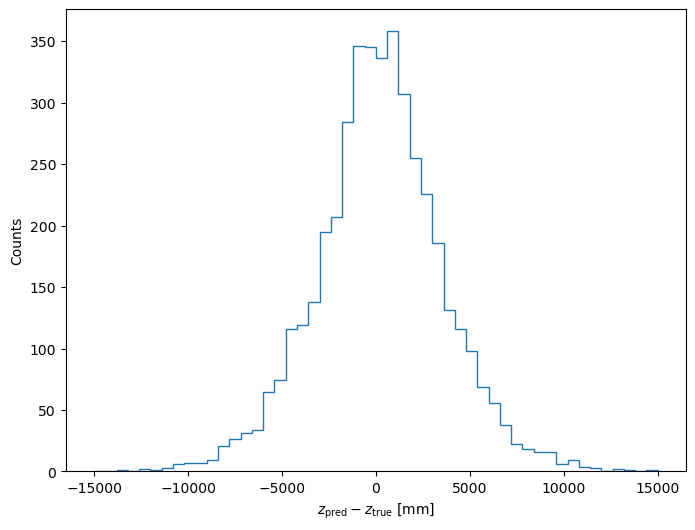

In [11]:
plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=50,
    histtype="step",
    range=[-15000,15000]
)

plt.xlabel(r"$z_{\mathrm{pred}} - z_{\mathrm{true}}$ [mm]")
plt.ylabel("Counts")

plt.show()

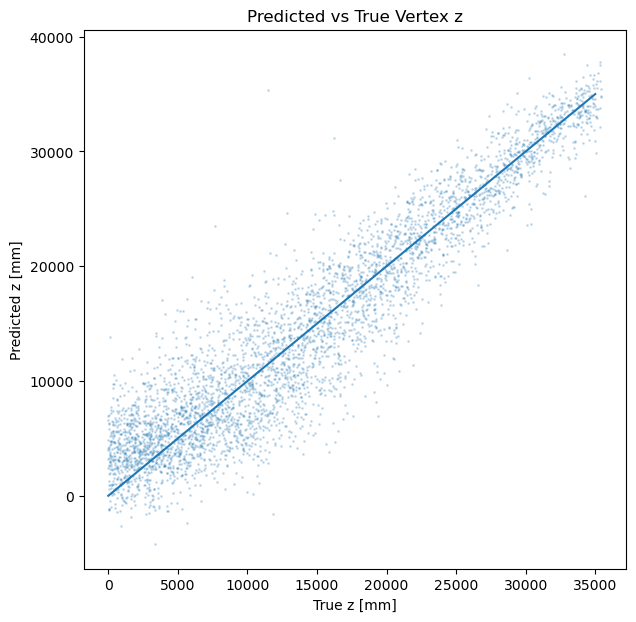

In [12]:
plt.figure(figsize=(7,7))

plt.scatter(
    z_true_all,
    z_pred_all,
    s=1,
    alpha=0.2,
)

zmin = min(z_true_all.min(), z_pred_all.min())
zmax = max(z_true_all.max(), z_pred_all.max())

plt.plot([0, 35000], [0, 35000])

plt.xlabel("True z [mm]")
plt.ylabel("Predicted z [mm]")

plt.title("Predicted vs True Vertex z")

plt.show()

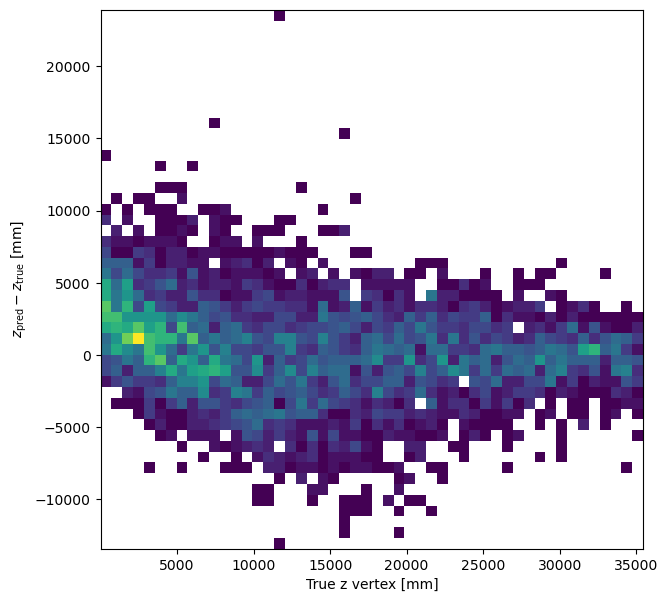

In [13]:
plt.figure(figsize=(7,7))

plt.hist2d(
    z_true_all,
    z_pred_all - z_true_all,
    cmin=1,
    bins=[50,50],
)

plt.xlabel("True z vertex [mm]")
plt.ylabel(r"$z_{\mathrm{pred}} - z_{\mathrm{true}}$ [mm]")

plt.show()

In [14]:
lam_mom = []
transverse_lam_mom = []

for event in test_events:

    lam_mom.append(np.sqrt(event["lam_mom_x"]**2 + event["lam_mom_y"]**2 + event["lam_mom_z"]**2))
    transverse_lam_mom.append(np.sqrt(event["lam_mom_x"]**2 + event["lam_mom_y"]**2))
    #transverse_lam_mom.append(np.sqrt(((event["lam_mom_x"] - (np.sin(-.025)*event["lam_mom_x"] + np.cos(-.025)*event["lam_mom_z"])*np.sin(-.025))**2 + event["lam_mom_y"]**2 + (event["lam_mom_z"] - (np.sin(-.025)*event["lam_mom_x"] + np.cos(-.025)*event["lam_mom_z"])*np.cos(-.025))**2)))


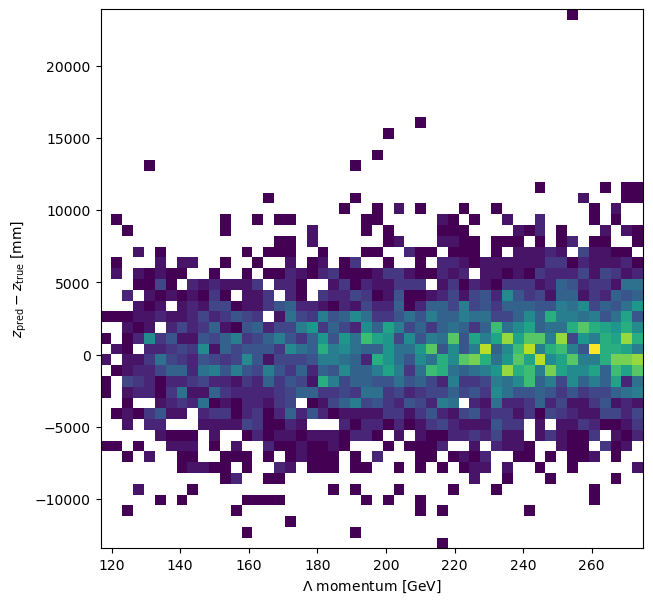

In [15]:
plt.figure(figsize=(7,7))

plt.hist2d(
    lam_mom,
    z_pred_all - z_true_all,
    cmin=1,
    bins=[50,50]
)

plt.xlabel(r"$\Lambda$ momentum [GeV]")
plt.ylabel(r"$z_{\mathrm{pred}} - z_{\mathrm{true}}$ [mm]")

plt.show()

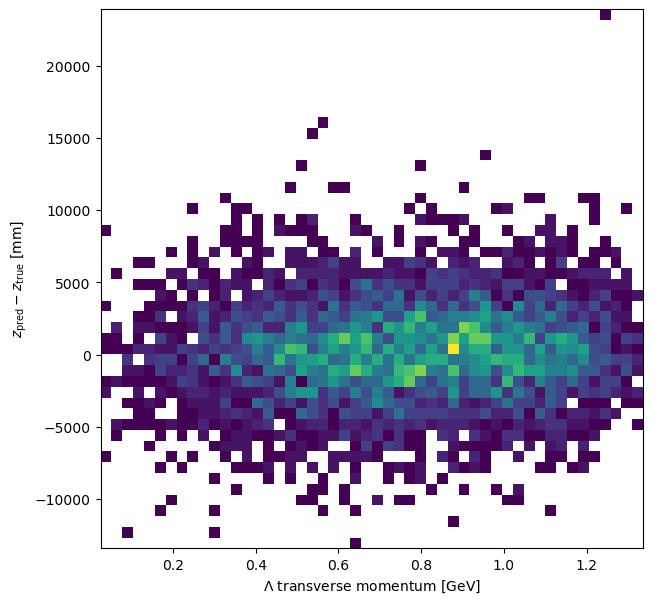

In [16]:
plt.figure(figsize=(7,7))

plt.hist2d(
    transverse_lam_mom,
    z_pred_all - z_true_all,
    cmin=1,
    bins=[50,50]
)

plt.xlabel(r"$\Lambda$ transverse momentum [GeV]")
plt.ylabel(r"$z_{\mathrm{pred}} - z_{\mathrm{true}}$ [mm]")

plt.show()